### Major Assignment (MLC-1)

#### Submitted By-

- Name- Amulya Shrivastava
- Section- 23412F3
- Registeration Number- 2341019456
- Serial Number- 59
- Group- 02

#### Diabetes Disease Diagnosis using SVM

This Python program implements a machine learning model to diagnose diabetes using a Support Vector Machine (SVM).

- Overview- The diabetes dataset is loaded from `sklearn.datasets` and converted into a DataFrame, with the target values changed into a binary classification.

- Data Preprocessing- The data is split into training and testing sets and normalized using `StandardScaler` for better model performance.

- Model Training- An `SVM classifier` with an `RBF kernel` is trained on the scaled training data to separate diabetic and non-diabetic cases.

- Model Evaluation- The model is evaluated using `accuracy`, `precision`, `recall`, and `F1-score`, along with a classification report and confusion matrix.

- Output- The results are printed to the console, the dataset is saved as a `Kaggle-ready CSV file`, and a confusion matrix graph is displayed.

        age       sex       bmi        bp        s1        s2        s3        s4        s5        s6  target
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401 -0.002592  0.019907 -0.017646   151.0
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412 -0.039493 -0.068332 -0.092204    75.0
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356 -0.002592  0.002861 -0.025930   141.0
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038  0.034309  0.022688 -0.009362   206.0
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142 -0.002592 -0.031988 -0.046641   135.0

 target
1    221
0    221
Name: count, dtype: int64

Dataset saved as diabetes_svm_dataset.csv

Training samples: (353, 10)
Testing samples: (89, 10)

Model Performance:
Accuracy : 0.7416
Precision: 0.7143
Recall   : 0.7955
F1-Score : 0.7527

Classification Report:

              precision    recall  f1-score   support

           0     

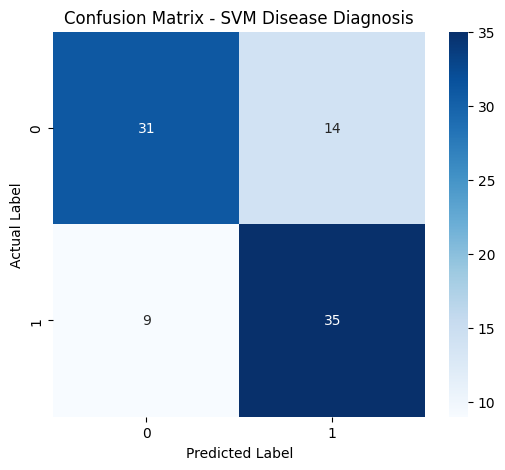

In [1]:
# Python Libraries import
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
diabetes=load_diabetes()
X=diabetes.data        # Features
y=diabetes.target      # Target (disease progression)

# Convert to DataFrame for easier handling
df=pd.DataFrame(X,columns=diabetes.feature_names)
df['target']=y
print(df.head().to_string()) # Display the starting 5 Data

# Convert continuous target to binary classes
# 1->Diseased,0->Not Diseased
df['target']=(df['target']>df['target'].median()).astype(int)
print("\n",df['target'].value_counts())

# Save dataset as CSV for Kaggle
df.to_csv("diabetes_svm_dataset.csv",index=False)
print("\nDataset saved as diabetes_svm_dataset.csv")

X=df.drop('target',axis=1)
y=df['target']

# Training the model on the basis of dataset
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Printing the data samples trained and tested on
print("\nTraining samples:",X_train.shape)
print("Testing samples:",X_test.shape)
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Initialize SVM with RBF kernel
svm_model=SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

# Train the model
svm_model.fit(X_train_scaled,y_train)
y_pred=svm_model.predict(X_test_scaled)

accuracy=accuracy_score(y_test, y_pred)
precision=precision_score(y_test, y_pred)
recall=recall_score(y_test, y_pred)
f1=f1_score(y_test, y_pred)

# Printing the required data
print("\nModel Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Report Preperation
print("\nClassification Report:\n")
report = classification_report(y_test,y_pred, digits=4)
print(report)
import sys
sys.stdout.flush()
cm = confusion_matrix(y_test,y_pred)

# Graph Visualization
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - SVM Disease Diagnosis")
plt.show()

In [2]:
# ---------------------------------------
# USER INPUT BASED DIABETES PREDICTION
# ---------------------------------------

print("\nEnter Patient Details for Diabetes Prediction")
user_data={}

for feature in diabetes.feature_names:
    user_data[feature]=float(input(f"Enter value for {feature}: "))

# Display entered details
print("\nEntered Patient Details:")
for key, value in user_data.items():
    print(f"{key} : {value}")

# Convert user input to DataFrame
user_df=pd.DataFrame([user_data])

# Scale using the same scaler
user_data_scaled=scaler.transform(user_df)

# Predict
prediction=svm_model.predict(user_data_scaled)

if prediction[0]==1:
    print("\nPrediction Result: DIABETIC")
else:
    print("\nPrediction Result: NOT DIABETIC")



Enter Patient Details for Diabetes Prediction

Entered Patient Details:
age : 0.038076
sex : 0.05068
bmi : 0.061696
bp : 0.021872
s1 : -0.044223
s2 : -0.034821
s3 : -0.043401
s4 : -0.002592
s5 : 0.019907
s6 : -0.017646

Prediction Result: DIABETIC
